Un modelo de absorción de fármacos, como bien dice el nombre simula el proceso de absorción de un compuesto farmacológico en el sistema, esto con las siguientes ED's: 
![ED de Absorción](resources/ED_ABS.PNG).


Tendremos x constantes y una función de administración/ingesta de los fármacos, que puede variar a una sola ingesta, o un consumo recurrente del mismo.

In [105]:
import matplotlib.pyplot as plt
import numpy as np

#Constantes del modelo de Absorción
alpha = 0.8 #Coeficiente de absorción
eta = 0.3 #Eliminación del fármaco
epsilon = 0.1 #Eficiencia de abosorción
delta = 50 #Dosis del fármaco

Designamos una ingesta ciclica.

In [106]:
def Ingesta1(delta,t):

    periodo = t % 24

    if 0 <= periodo < 1:
        return delta

    return 0

Y una ingesta única.

In [107]:
def Ingesta2(delta,t):
    #Designamos un consumo despues de 2 horas
    if t == 2:
        return delta
    return 0

Definimos el sistema de ED's y la simulación del mismo

In [108]:
def ABS(alpha, eta, epsilon, delta, A, B, t):
    dA = -(alpha-epsilon)*A + Ingesta1(delta,t)
    dB = (alpha-epsilon)*A - eta*B
    return dA, dB

In [109]:
def sim_ABS(alpha, eta, epsilon, delta, t_max):
    dt = 0.001 #Paso de tiempo
    A = np.zeros(t_max)
    B = np.zeros(t_max)
    A[0], B[0] = 0, 0 #Condiciones iniciales
    for t in range(1, t_max):
        dA, dB = ABS(alpha, eta, epsilon, delta, A[t-1], B[t-1], t)
        A[t] = A[t-1] + dA * dt
        B[t] = B[t-1] + dB * dt
    return A, B

Graficamos A y B como la evolución temporal.

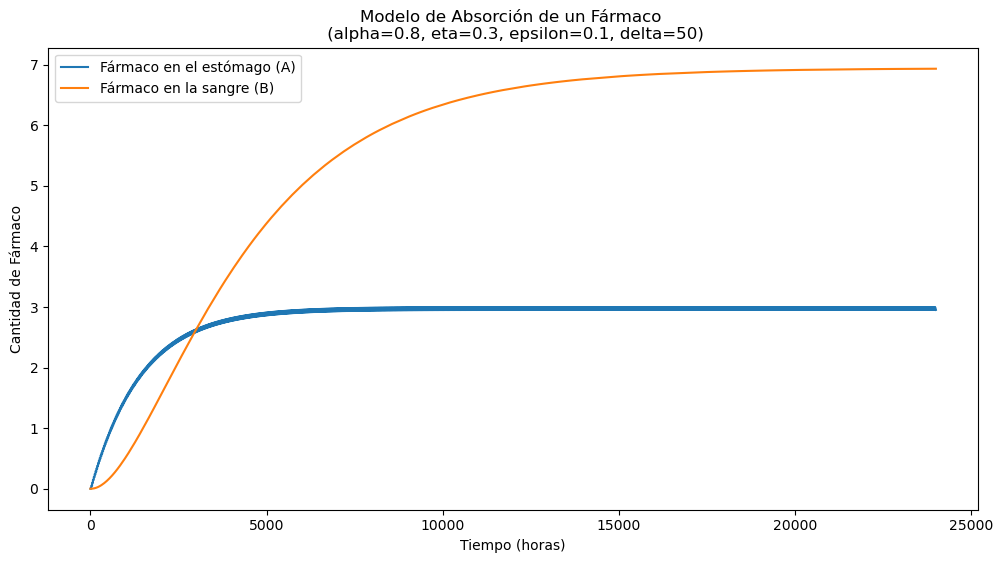

In [110]:
A, B = sim_ABS(alpha, eta, epsilon, delta, 24000) #Simulamos por 2400 horas

#Graficamos los resultados
plt.figure(figsize=(12, 6))
plt.plot(A, label='Fármaco en el estómago (A)')
plt.plot(B, label='Fármaco en la sangre (B)')
plt.title('Modelo de Absorción de un Fármaco \n (alpha={}, eta={}, epsilon={}, delta={})'.format(alpha, eta, epsilon, delta))
plt.xlabel('Tiempo (horas)')
plt.ylabel('Cantidad de Fármaco')
plt.legend()
plt.show()

Referencias:

-[Modelado biologico de la absorción del Medicamento](https://ri.conicet.gov.ar/bitstream/handle/11336/159251/CONICET_Digital_Nro.3858249a-7712-4e07-86f0-340243fdd00d_A.pdf?sequence=2)

-[Modelado de absorción oral de medicamentos](https://pmc.ncbi.nlm.nih.gov/articles/PMC2691458/)